<a href="https://colab.research.google.com/github/bgorume/exercise3_univariate_analysis.ipynb/blob/main/exercise3_univariate_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
f = pd.read_csv('EFIplus_medit.csv', sep=";")
print('Dataset shape:', f.shape)
f.head()

Dataset shape: (5011, 164)


,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Find the 4 catchments with the most fish sampling sites
top4 = f['Catchment_name'].value_counts().head(4)
print(top4)

# Filter the data to only include those 4 catchments
top4_names = top4.index.tolist()
df_top4 = f[f['Catchment_name'].isin(top4_names)]

print(f'Total sites in top 4 catchments: {df_top4.shape[0]}')

Catchment_name
Ebro            736
Galiza-Norte    709
Minho           707
Tejo            509
Name: count, dtype: int64
Total sites in top 4 catchments: 2661


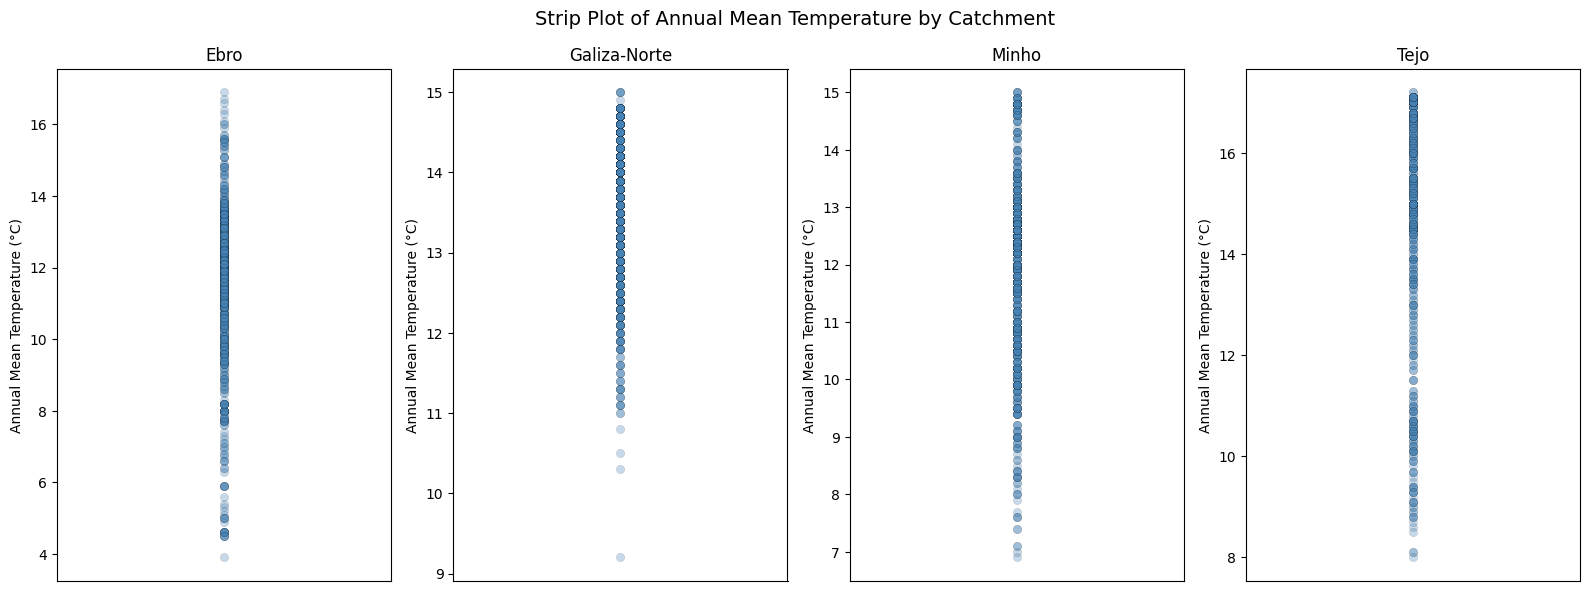

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 6))

for i, catchment in enumerate(top4_names):
    data = df_top4[df_top4['Catchment_name'] == catchment]['temp_ann']
    axes[i].scatter([0]*len(data), data, alpha=0.3, color='steelblue',
                    edgecolors='k', linewidths=0.2)
    axes[i].set_title(catchment)
    axes[i].set_xlabel('')
    axes[i].set_xticks([])
    axes[i].set_ylabel('Annual Mean Temperature (°C)')

plt.suptitle('Strip Plot of Annual Mean Temperature by Catchment', fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_164/1864698253.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_means, labels=sample_sizes)


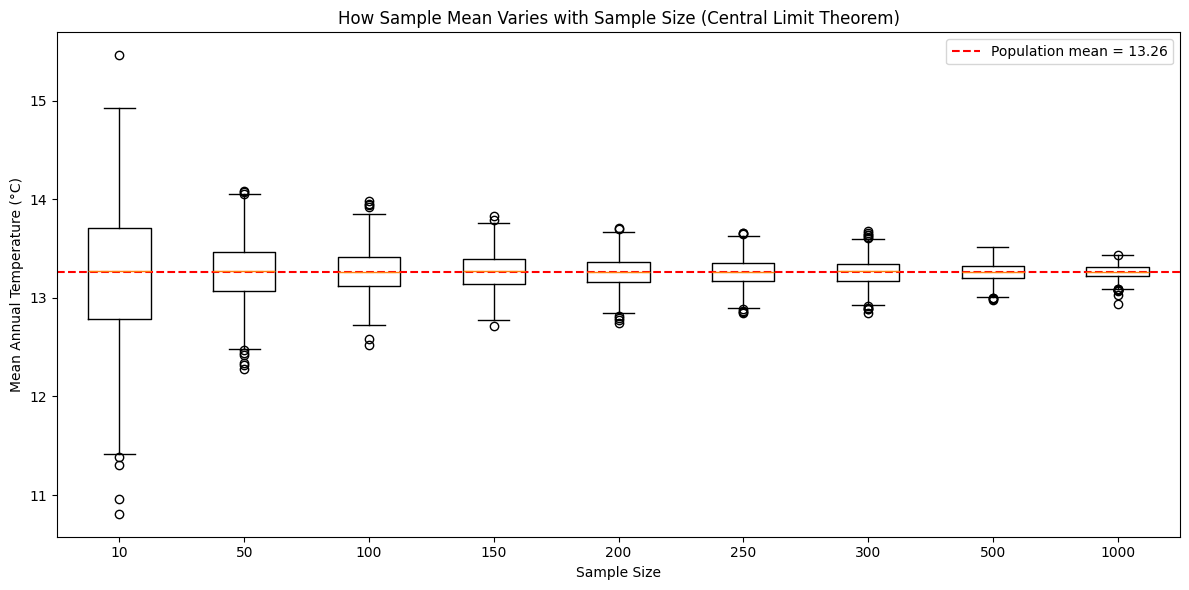

In [5]:
# Define sample sizes to test
sample_sizes = [10, 50, 100, 150, 200, 250, 300, 500, 1000]

# Get the temp_ann column without missing values
temp_data = f['temp_ann'].dropna().values

# Take 1000 random samples for each sample size and calculate the mean
all_means = []
for size in sample_sizes:
    means = [np.mean(np.random.choice(temp_data, size=size, replace=True))
             for _ in range(1000)]
    all_means.append(means)

# Plot the results
fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(all_means, labels=sample_sizes)
ax.axhline(y=np.mean(temp_data), color='red', linestyle='--',
           label=f'Population mean = {np.mean(temp_data):.2f}')
ax.set_xlabel('Sample Size')
ax.set_ylabel('Mean Annual Temperature (°C)')
ax.set_title('How Sample Mean Varies with Sample Size (Central Limit Theorem)')
ax.legend()
plt.tight_layout()
plt.show()